# Tennis Match Winner Prediction

## 1. Data Loading and Inspection

In [1]:
import numpy as np
import pandas as pd

from config import (
    COLS_TO_DROP, COLS_TO_DROP_RAND,
    round_order, series_order, ODDS_COLS,
)
from features import compute_all_features
from models import evaluate_model, report_model, report_ann, plot_roc_curves, report_error_analysis

years = range(2019, 2026)
dataframes = []

for year in years:
    df_year = pd.read_excel(f"data/{year}.xlsx")
    df_year["Year"] = year
    dataframes.append(df_year)

df = pd.concat(dataframes, ignore_index=True)

print(f"Total shape: {df.shape}")
print(f"Years present: {df['Year'].unique()}")

Total shape: (17048, 39)
Years present: [2019 2020 2021 2022 2023 2024 2025]


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17048 entries, 0 to 17047
Data columns (total 39 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ATP         17048 non-null  int64         
 1   Location    17048 non-null  str           
 2   Tournament  17048 non-null  str           
 3   Date        17048 non-null  datetime64[us]
 4   Series      17048 non-null  str           
 5   Court       17048 non-null  str           
 6   Surface     17048 non-null  str           
 7   Round       17048 non-null  str           
 8   Best of     17033 non-null  float64       
 9   Winner      17048 non-null  str           
 10  Loser       17048 non-null  str           
 11  WRank       17041 non-null  float64       
 12  LRank       17010 non-null  float64       
 13  WPts        17042 non-null  float64       
 14  LPts        17010 non-null  float64       
 15  W1          16923 non-null  float64       
 16  L1          16924 non-null  float

## 2. Data Preparation

### 2.1 Cleaning

In [3]:
# Remove non completed matches 
df = df[df["Comment"] == "Completed"].copy()
print(f"Shape after removing non Completed: {df.shape}")

# Drop post-match, leakage, and irrelevant columns
df = df.drop(columns=COLS_TO_DROP)
print(f"Shape after drop: {df.shape}")
print(f"Remaining columns:\n{df.columns.tolist()}")

Shape after removing non Completed: (16463, 39)
Shape after drop: (16463, 17)
Remaining columns:
['Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'AvgW', 'AvgL', 'Year']


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 16463 entries, 0 to 17047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Location    16463 non-null  str           
 1   Tournament  16463 non-null  str           
 2   Date        16463 non-null  datetime64[us]
 3   Series      16463 non-null  str           
 4   Court       16463 non-null  str           
 5   Surface     16463 non-null  str           
 6   Round       16463 non-null  str           
 7   Best of     16448 non-null  float64       
 8   Winner      16463 non-null  str           
 9   Loser       16463 non-null  str           
 10  WRank       16456 non-null  float64       
 11  LRank       16425 non-null  float64       
 12  WPts        16457 non-null  float64       
 13  LPts        16425 non-null  float64       
 14  AvgW        16451 non-null  float64       
 15  AvgL        16451 non-null  float64       
 16  Year        16463 non-null  int64     

### 2.2 Missing Values Handling

In [5]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing": missing, "Missing %": missing_pct}).query("Missing > 0")

,Missing,Missing %
Best of,15,0.09
WRank,7,0.04
LRank,38,0.23
WPts,6,0.04
LPts,38,0.23
AvgW,12,0.07
AvgL,12,0.07


In [6]:
# Best of missing: mode + indicator
bestof_mode = df["Best of"].mode()[0]
df["Best of_missing"] = df["Best of"].isnull().astype(int)
df["Best of"] = df["Best of"].fillna(bestof_mode)

# WRank, LRank missing: 500 + indicator
df["WRank_missing"] = df["WRank"].isnull().astype(int)
df["LRank_missing"] = df["LRank"].isnull().astype(int)
df["WRank"] = df["WRank"].fillna(500)
df["LRank"] = df["LRank"].fillna(500)

# WPts, LPts missing: 0 + indicator
df["WPts_missing"] = df["WPts"].isnull().astype(int)
df["LPts_missing"] = df["LPts"].isnull().astype(int)
df["WPts"] = df["WPts"].fillna(0)
df["LPts"] = df["LPts"].fillna(0)

# Avg bookmaker odds missing: median + indicator
df["odds_missing"] = df["AvgW"].isnull().astype(int)
df["AvgW"] = df["AvgW"].fillna(df["AvgW"].median())
df["AvgL"] = df["AvgL"].fillna(df["AvgL"].median())

print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nNo missing values" if df.isnull().sum().sum() == 0 else "")

Remaining missing values:
Series([], dtype: int64)

No missing values


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 16463 entries, 0 to 17047
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Location         16463 non-null  str           
 1   Tournament       16463 non-null  str           
 2   Date             16463 non-null  datetime64[us]
 3   Series           16463 non-null  str           
 4   Court            16463 non-null  str           
 5   Surface          16463 non-null  str           
 6   Round            16463 non-null  str           
 7   Best of          16463 non-null  float64       
 8   Winner           16463 non-null  str           
 9   Loser            16463 non-null  str           
 10  WRank            16463 non-null  float64       
 11  LRank            16463 non-null  float64       
 12  WPts             16463 non-null  float64       
 13  LPts             16463 non-null  float64       
 14  AvgW             16463 non-null  float64       
 15  A

### 2.3 Randomization and Target

In [8]:
np.random.seed(42)

# Random assignment: True = Winner goes to P1, False = Winner goes to P2
mask = np.random.rand(len(df)) > 0.5

df["y"] = mask.astype(int)
df["Player1"] = np.where(mask, df["Winner"], df["Loser"])
df["Player2"] = np.where(mask, df["Loser"],  df["Winner"])

df["P1Rank"] = np.where(mask, df["WRank"], df["LRank"])
df["P2Rank"] = np.where(mask, df["LRank"], df["WRank"])
df["P1Pts"]  = np.where(mask, df["WPts"],  df["LPts"])
df["P2Pts"]  = np.where(mask, df["LPts"],  df["WPts"])

df["P1Rank_missing"] = np.where(mask, df["WRank_missing"], df["LRank_missing"])
df["P2Rank_missing"] = np.where(mask, df["LRank_missing"], df["WRank_missing"])
df["P1Pts_missing"]  = np.where(mask, df["WPts_missing"],  df["LPts_missing"])
df["P2Pts_missing"]  = np.where(mask, df["LPts_missing"],  df["WPts_missing"])

df["Avg_P1"] = np.where(mask, df["AvgW"], df["AvgL"])
df["Avg_P2"] = np.where(mask, df["AvgL"], df["AvgW"])

# remove cols without rand
df = df.drop(columns=COLS_TO_DROP_RAND)

df.columns.tolist()

['Location',
 'Tournament',
 'Date',
 'Series',
 'Court',
 'Surface',
 'Round',
 'Best of',
 'Year',
 'Best of_missing',
 'odds_missing',
 'y',
 'Player1',
 'Player2',
 'P1Rank',
 'P2Rank',
 'P1Pts',
 'P2Pts',
 'P1Rank_missing',
 'P2Rank_missing',
 'P1Pts_missing',
 'P2Pts_missing',
 'Avg_P1',
 'Avg_P2']

### 2.4 Categorical Variables Encoding

In [9]:
# Court: binary to 0/1
df["Court"] = df["Court"].map({"Outdoor": 0, "Indoor": 1})

# Surface: nominal to one-hot encoding
df = pd.get_dummies(df, columns=["Surface"], prefix="Surface")

# Round: ordinal encoding
df["Round"] = df["Round"].map(round_order)

# Series: ordinal encoding
df["Series"] = df["Series"].map(series_order)

print("NaN after encoding:")
print(df[["Court", "Round", "Series"]].isnull().sum())

NaN after encoding:
Court     0
Round     0
Series    0
dtype: int64


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 16463 entries, 0 to 17047
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Location         16463 non-null  str           
 1   Tournament       16463 non-null  str           
 2   Date             16463 non-null  datetime64[us]
 3   Series           16463 non-null  int64         
 4   Court            16463 non-null  int64         
 5   Round            16463 non-null  int64         
 6   Best of          16463 non-null  float64       
 7   Year             16463 non-null  int64         
 8   Best of_missing  16463 non-null  int64         
 9   odds_missing     16463 non-null  int64         
 10  y                16463 non-null  int64         
 11  Player1          16463 non-null  str           
 12  Player2          16463 non-null  str           
 13  P1Rank           16463 non-null  float64       
 14  P2Rank           16463 non-null  float64       
 15  P

### 2.5 Feature Engineering: Historical Statistics

In [11]:
# total win rate
# surface win rate
# recent 20 games
# h2h
# differential features

df = compute_all_features(df)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16463 entries, 0 to 16462
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   y                      16463 non-null  int64         
 1   Year                   16463 non-null  int64         
 2   Date                   16463 non-null  datetime64[us]
 3   Location               16463 non-null  str           
 4   Tournament             16463 non-null  str           
 5   Series                 16463 non-null  int64         
 6   Court                  16463 non-null  int64         
 7   Round                  16463 non-null  int64         
 8   Best of                16463 non-null  float64       
 9   Surface_Clay           16463 non-null  int64         
 10  Surface_Grass          16463 non-null  int64         
 11  Surface_Hard           16463 non-null  int64         
 12  Player1                16463 non-null  str           
 13  Player2     

### 2.6 Differential Features and Train/Test Split

In [13]:
# Temporal split: train on 2019-2024, test on 2025
X_train = df[df["Year"] <= 2024].drop(columns=["y", "Year", "Date", "Location", "Tournament", "Player1", "Player2"])
y_train = df[df["Year"] <= 2024]["y"]

X_test = df[df["Year"] == 2025].drop(columns=["y", "Year", "Date", "Location", "Tournament", "Player1", "Player2"])
y_test = df[df["Year"] == 2025]["y"]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train.info()


X_train: (13944, 21)
X_test:  (2519, 21)
<class 'pandas.DataFrame'>
RangeIndex: 13944 entries, 0 to 13943
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Series                 13944 non-null  int64  
 1   Court                  13944 non-null  int64  
 2   Round                  13944 non-null  int64  
 3   Best of                13944 non-null  float64
 4   Surface_Clay           13944 non-null  int64  
 5   Surface_Grass          13944 non-null  int64  
 6   Surface_Hard           13944 non-null  int64  
 7   rank_diff              13944 non-null  float64
 8   pts_diff               13944 non-null  float64
 9   win_rate_diff          13944 non-null  float64
 10  win_rate_surface_diff  13944 non-null  float64
 11  recent_win_rate_diff   13944 non-null  float64
 12  h2h_win_rate_diff      13944 non-null  float64
 13  Avg_P1                 13944 non-null  float64
 14  Avg_P2                 1

## 3. Baseline Models

### 3.1 ATP Ranking Baseline

In [14]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Baseline: player with lowest ranking wins
print('=== BASELINE (RANKING ATP) ===')

y_pred_baseline_rank_train = (X_train["rank_diff"] < 0).astype(int)
y_pred_baseline_rank_test  = (X_test["rank_diff"] < 0).astype(int)

print(f'TRAIN accuracy: {accuracy_score(y_train, y_pred_baseline_rank_train):.4f}')
print(f'TEST accuracy: {accuracy_score(y_test, y_pred_baseline_rank_test):.4f}')
print()
print(f'TRAIN AUC-ROC: {roc_auc_score(y_train, y_pred_baseline_rank_train):.4f}')
print(f'TEST AUC-ROC: {roc_auc_score(y_test, y_pred_baseline_rank_test):.4f}')
print('\nCLASSIFICATION REPORT (TEST)')
print(classification_report(y_test, y_pred_baseline_rank_test))

=== BASELINE (RANKING ATP) ===
TRAIN accuracy: 0.6332
TEST accuracy: 0.6479

TRAIN AUC-ROC: 0.6332
TEST AUC-ROC: 0.6479

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      1257
           1       0.65      0.63      0.64      1262

    accuracy                           0.65      2519
   macro avg       0.65      0.65      0.65      2519
weighted avg       0.65      0.65      0.65      2519



### 3.2 Bookmaker Odds Baseline

In [15]:
# Baseline: player with lowest average odds wins
avg_odds_p1_train = X_train["Avg_P1"]
avg_odds_p2_train = X_train["Avg_P2"]
y_pred_baseline_train = (avg_odds_p1_train < avg_odds_p2_train).astype(int)

avg_odds_p1_test = X_test["Avg_P1"]
avg_odds_p2_test = X_test["Avg_P2"]
y_pred_baseline_test = (avg_odds_p1_test < avg_odds_p2_test).astype(int)

print('=== BASELINE (BOOKMAKER ODDS) ===')
print(f'TRAIN  accuracy: {accuracy_score(y_train, y_pred_baseline_train):.4f}')
try:
    p1_train = (1/avg_odds_p1_train) / ((1/avg_odds_p1_train) + (1/avg_odds_p2_train))
    print(f'TRAIN  AUC-ROC: {roc_auc_score(y_train, p1_train):.4f}')
except Exception:
    pass

print(f'\nTEST  accuracy: {accuracy_score(y_test, y_pred_baseline_test):.4f}')
try:
    p1_test = (1/avg_odds_p1_test) / ((1/avg_odds_p1_test) + (1/avg_odds_p2_test))
    print(f'TEST  AUC-ROC: {roc_auc_score(y_test, p1_test):.4f}')
except Exception:
    pass

print('\nCLASSIFICATION REPORT (TEST)')
print(classification_report(y_test, y_pred_baseline_test))

=== BASELINE (BOOKMAKER ODDS) ===
TRAIN  accuracy: 0.6821
TRAIN  AUC-ROC: 0.7535

TEST  accuracy: 0.6804
TEST  AUC-ROC: 0.7456

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.67      0.70      0.69      1257
           1       0.69      0.66      0.68      1262

    accuracy                           0.68      2519
   macro avg       0.68      0.68      0.68      2519
weighted avg       0.68      0.68      0.68      2519



## 4. Predictive Models

### 4.1 XGBoost

XGBoost loaded from disk.

XGBoost — Tuned model
=== TRAINING ===
Accuracy: 0.6842
AUC-ROC:  0.7595
=== TEST ===
Accuracy: 0.6808
AUC-ROC:  0.7441
=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.68      0.69      0.68      1257
           1       0.69      0.67      0.68      1262

    accuracy                           0.68      2519
   macro avg       0.68      0.68      0.68      2519
weighted avg       0.68      0.68      0.68      2519


XGBoost — Feature Importance
              feature  importance
               Avg_P1    0.338823
               Avg_P2    0.256508
            rank_diff    0.114194
             pts_diff    0.089901
        win_rate_diff    0.042322
 recent_win_rate_diff    0.030085
               Series    0.025565
win_rate_surface_diff    0.022155
    h2h_win_rate_diff    0.022052
                Court    0.015920
                Round    0.015190
              Best of    0.014289
         Surface_

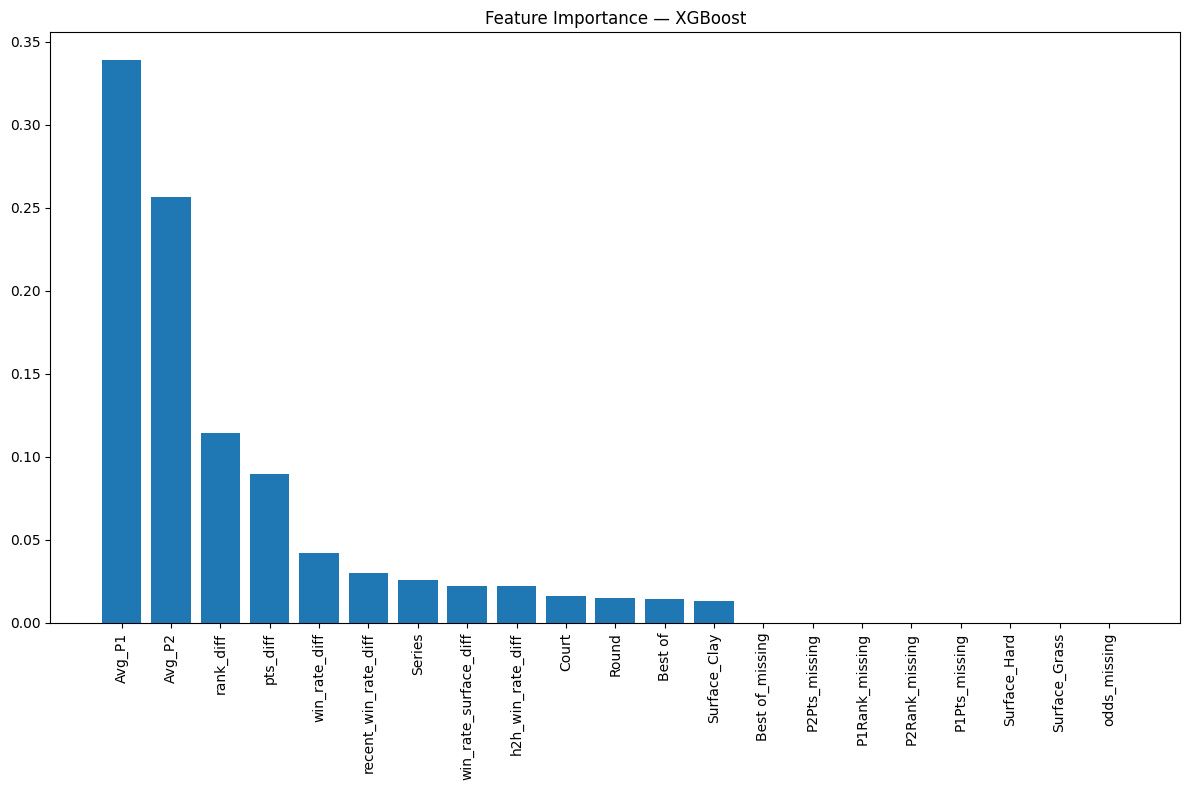


XGBoost — Final model with selected features
Selected features: ['Series', 'Best of', 'rank_diff', 'pts_diff', 'win_rate_diff', 'win_rate_surface_diff', 'recent_win_rate_diff', 'h2h_win_rate_diff', 'Avg_P1', 'Avg_P2']
Final accuracy: 0.6800
Final AUC-ROC:  0.7432

XGBoost — Without bookmaker odds
Accuracy without odds: 0.6475
AUC-ROC without odds:  0.7099

XGBoost — Summary
Variant        Accuracy    AUC-ROC
----------------------------------
Tuned            0.6808     0.7441
RFECV            0.6800     0.7432
No odds          0.6475     0.7099


In [16]:
import joblib, json, os
from xgboost import XGBClassifier

os.makedirs("models", exist_ok=True)

# Load model
if os.path.exists("models/xgb_best.pkl"):
    xgb_best = joblib.load("models/xgb_best.pkl")
    xgb_final = joblib.load("models/xgb_final.pkl")
    xgb_no_odds = joblib.load("models/xgb_no_odds.pkl")
    with open("models/xgb_features.json") as f:
        xgb_features = json.load(f)
    print("XGBoost loaded from disk.")
    
    report_model(xgb_best, xgb_features, xgb_final, xgb_no_odds,
                 X_train, X_test, y_train, y_test, "XGBoost")
    
else:
    
    xgb_params = {
        "n_estimators": [100, 300, 500],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
    }
    xgb_best, xgb_features, xgb_final, xgb_no_odds = evaluate_model(
        XGBClassifier(random_state=42, eval_metric="logloss"),
        xgb_params,
        X_train, X_test, y_train, y_test,
        model_name="XGBoost",
    )
    joblib.dump(xgb_best, "models/xgb_best.pkl")
    joblib.dump(xgb_final, "models/xgb_final.pkl")
    joblib.dump(xgb_no_odds, "models/xgb_no_odds.pkl")
    with open("models/xgb_features.json", "w") as f:
        json.dump(xgb_features, f)


### 4.2 Random Forest

Random Forest loaded from disk.

Random Forest — Tuned model
=== TRAINING ===
Accuracy: 0.6857
AUC-ROC:  0.7607
=== TEST ===
Accuracy: 0.6792
AUC-ROC:  0.7425
=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.67      0.69      0.68      1257
           1       0.68      0.67      0.68      1262

    accuracy                           0.68      2519
   macro avg       0.68      0.68      0.68      2519
weighted avg       0.68      0.68      0.68      2519


Random Forest — Feature Importance
              feature  importance
               Avg_P2    0.338144
               Avg_P1    0.282137
             pts_diff    0.119989
            rank_diff    0.118114
        win_rate_diff    0.050003
 recent_win_rate_diff    0.034615
win_rate_surface_diff    0.034496
    h2h_win_rate_diff    0.007809
               Series    0.005460
                Round    0.002712
              Best of    0.002231
        Surface_Grass    0.000768

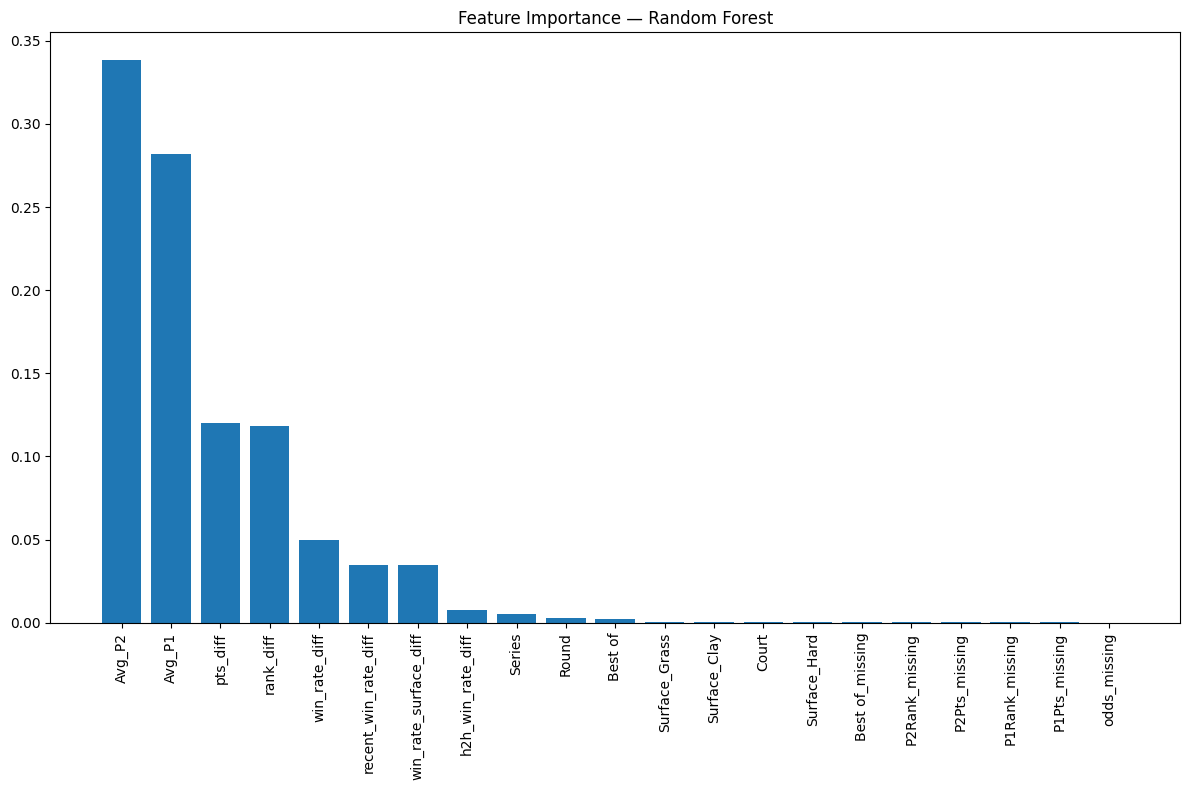


Random Forest — Final model with selected features
Selected features: ['Series', 'Round', 'Best of', 'Surface_Grass', 'rank_diff', 'pts_diff', 'win_rate_diff', 'win_rate_surface_diff', 'recent_win_rate_diff', 'h2h_win_rate_diff', 'Avg_P1', 'Avg_P2']
Final accuracy: 0.6828
Final AUC-ROC:  0.7440

Random Forest — Without bookmaker odds
Accuracy without odds: 0.6503
AUC-ROC without odds:  0.7107

Random Forest — Summary
Variant        Accuracy    AUC-ROC
----------------------------------
Tuned            0.6792     0.7425
RFECV            0.6828     0.7440
No odds          0.6503     0.7107


In [17]:
from sklearn.ensemble import RandomForestClassifier

if os.path.exists("models/rf_best.pkl"):
    rf_best = joblib.load("models/rf_best.pkl")
    rf_final = joblib.load("models/rf_final.pkl")
    rf_no_odds = joblib.load("models/rf_no_odds.pkl")
    with open("models/rf_features.json") as f:
        rf_features = json.load(f)
    print("Random Forest loaded from disk.")
    
    report_model(rf_best, rf_features, rf_final, rf_no_odds,
                 X_train, X_test, y_train, y_test, "Random Forest")
    
else:
    
    rf_params = {
        "n_estimators": [100, 300],
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    }
    rf_best, rf_features, rf_final, rf_no_odds = evaluate_model(
        RandomForestClassifier(random_state=42),
        rf_params,
        X_train, X_test, y_train, y_test,
        model_name="Random Forest",
    )
    joblib.dump(rf_best, "models/rf_best.pkl")
    joblib.dump(rf_final, "models/rf_final.pkl")
    joblib.dump(rf_no_odds, "models/rf_no_odds.pkl")
    with open("models/rf_features.json", "w") as f:
        json.dump(rf_features, f)


### 4.3 Artificial Neural Network (ANN)

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

if os.path.exists("models/ann_v1.keras"):
    model_ann = keras.models.load_model("models/ann_v1.keras")
    scaler = joblib.load("models/scaler.pkl")
    print("ANN v1 loaded from disk.")
    
else:


    model_ann = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    
    model_ann.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    
    model_ann.fit(
        X_train_scaled, y_train,
        epochs=100, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1,
    )
    
    model_ann.save("models/ann_v1.keras")
    joblib.dump(scaler, "models/scaler.pkl")
    
report_ann(model_ann, X_train_scaled, X_test_scaled, y_train, y_test, "ANN v1")


ANN v1 loaded from disk.

ANN v1 — Results
=== TRAINING ===
Accuracy: 0.6847
AUC-ROC:  0.7576
=== TEST ===
Accuracy: 0.6749
AUC-ROC:  0.7359
=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.66      0.71      0.69      1257
           1       0.69      0.64      0.66      1262

    accuracy                           0.67      2519
   macro avg       0.68      0.67      0.67      2519
weighted avg       0.68      0.67      0.67      2519



In [19]:
if os.path.exists("models/ann_v2.keras"):
    model_ann_v2 = keras.models.load_model("models/ann_v2.keras")
    print("ANN v2 loaded from disk.")
    
else:

    model_ann_v2 = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model_ann_v2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    model_ann_v2.fit(
        X_train_scaled, y_train,
        epochs=100, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1,
    )
    model_ann_v2.save("models/ann_v2.keras")
    print("ANN v2 saved.")

report_ann(model_ann_v2, X_train_scaled, X_test_scaled, y_train, y_test, "ANN v2")

ANN v2 loaded from disk.

ANN v2 — Results
=== TRAINING ===
Accuracy: 0.6851
AUC-ROC:  0.7587
=== TEST ===
Accuracy: 0.6848
AUC-ROC:  0.7417
=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1257
           1       0.70      0.66      0.68      1262

    accuracy                           0.68      2519
   macro avg       0.69      0.68      0.68      2519
weighted avg       0.69      0.68      0.68      2519



In [20]:
if os.path.exists("models/ann_no_odds.keras"):
    model_ann_no_odds = keras.models.load_model("models/ann_no_odds.keras")
    scaler_no_odds = joblib.load("models/scaler_no_odds.pkl")
    X_train_no_odds = X_train.drop(columns=ODDS_COLS)
    X_test_no_odds = X_test.drop(columns=ODDS_COLS)
    X_train_no_odds_sc = scaler_no_odds.transform(X_train_no_odds)
    X_test_no_odds_sc = scaler_no_odds.transform(X_test_no_odds)
    print("ANN no odds loaded from disk.")
    
else:

    X_train_no_odds = X_train.drop(columns=ODDS_COLS)
    X_test_no_odds  = X_test.drop(columns=ODDS_COLS)

    scaler_no_odds = StandardScaler()
    X_train_no_odds_sc = scaler_no_odds.fit_transform(X_train_no_odds)
    X_test_no_odds_sc  = scaler_no_odds.transform(X_test_no_odds)

    model_ann_no_odds = keras.Sequential([
        layers.Input(shape=(X_train_no_odds.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model_ann_no_odds.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    model_ann_no_odds.fit(
        X_train_no_odds_sc, y_train,
        epochs=100, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1,
    )
    model_ann_no_odds.save("models/ann_no_odds.keras")
    joblib.dump(scaler_no_odds, "models/scaler_no_odds.pkl")
    print("ANN no odds saved.")

report_ann(model_ann_no_odds, X_train_no_odds_sc, X_test_no_odds_sc, y_train, y_test, "ANN no odds")

ANN no odds loaded from disk.

ANN no odds — Results
=== TRAINING ===
Accuracy: 0.6512
AUC-ROC:  0.7134
=== TEST ===
Accuracy: 0.6471
AUC-ROC:  0.7055
=== CLASSIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0       0.64      0.69      0.66      1257
           1       0.66      0.61      0.63      1262

    accuracy                           0.65      2519
   macro avg       0.65      0.65      0.65      2519
weighted avg       0.65      0.65      0.65      2519



## 6. Error Analysis

## 6.1 ROC Curve — Model Comparison

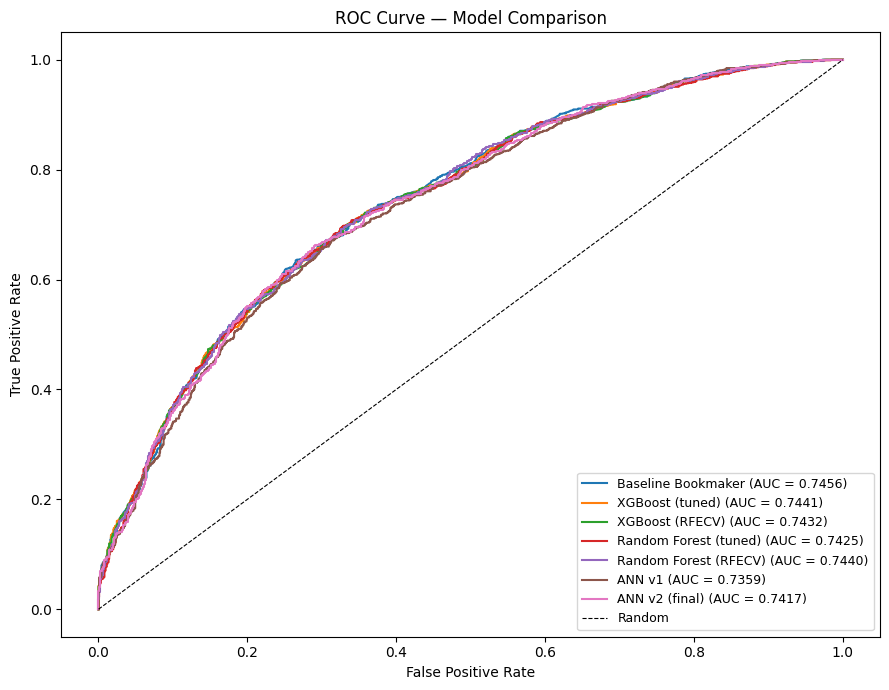

In [21]:
odds_p1 = X_test["Avg_P1"]
odds_p2 = X_test["Avg_P2"]
prob_bk = 1/odds_p1 / (1/odds_p1 + 1/odds_p2)

models_roc = {
    "Baseline Bookmaker": prob_bk.values,
    "XGBoost (tuned)": xgb_best.predict_proba(X_test)[:, 1],
    "XGBoost (RFECV)": xgb_final.predict_proba(X_test[xgb_features])[:, 1],
    "Random Forest (tuned)": rf_best.predict_proba(X_test)[:, 1],
    "Random Forest (RFECV)": rf_final.predict_proba(X_test[rf_features])[:, 1],
    "ANN v1": model_ann.predict(X_test_scaled, verbose=0).flatten(),
    "ANN v2 (final)": model_ann_v2.predict(X_test_scaled, verbose=0).flatten(),
}

plot_roc_curves(models_roc, y_test)

High confidence (>0.7) correct:   630
High confidence (>0.7) incorrect: 157



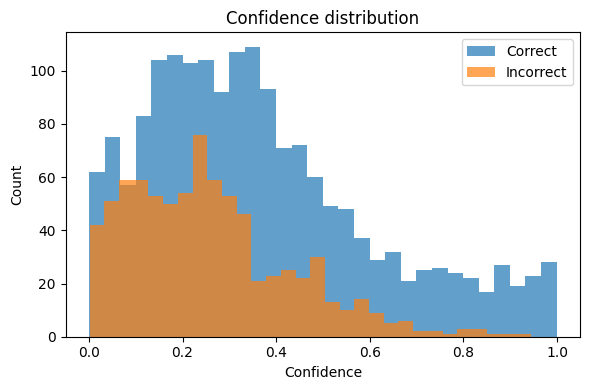


Accuracy by surface:
surface
Clay     0.6880
Grass    0.6969
Hard     0.6809
Name: Accuracy, dtype: float64

Accuracy by tournament stage:
stage
Early rounds (1-2)     0.6717
Middle rounds (3-4)    0.7889
Late stages (5+)       0.6750
Name: Accuracy, dtype: float64

Accuracy by ranking gap:
gap_rank
Small gap (0-10)      0.6585
Medium gap (10-50)    0.6567
Large gap (50-200)    0.7244
Huge gap (200+)       0.7208
Name: Accuracy, dtype: float64

High confidence  (prob > 0.7 o < 0.3): 787 predictions → accuracy 0.8005 (80.05%)
Low confidence (prob in [0.3, 0.7]): 1732 predictions → accuracy 0.6322 (63.22%)


In [ ]:
y_prob_v2 = model_ann_v2.predict(X_test_scaled, verbose=0).flatten()
y_pred_v2 = (y_prob_v2 > 0.5).astype(int)

report_error_analysis(y_test.values, y_pred_v2, y_prob_v2, X_test)

# Confidence split accuracy
high_mask = (y_prob_v2 > 0.7) | (y_prob_v2 < 0.3)
low_mask  = ~high_mask

high_acc = accuracy_score(y_test.values[high_mask], y_pred_v2[high_mask])
low_acc = accuracy_score(y_test.values[low_mask],  y_pred_v2[low_mask])

print(f"\nHigh confidence  (prob > 0.7 o < 0.3): {high_mask.sum()} predictions → accuracy {high_acc:.4f} ({100*high_acc:.2f}%)")
print(f"Low confidence (prob in [0.3, 0.7]): {low_mask.sum()} predictions → accuracy {low_acc:.4f} ({100*low_acc:.2f}%)")

## 7. Final Summary

In [23]:
rank_acc  = accuracy_score(y_test, (X_test["rank_diff"] < 0).astype(int))
rank_auc  = roc_auc_score(y_test,  (X_test["rank_diff"] < 0).astype(int))

avg_p1 = X_test["Avg_P1"]
avg_p2 = X_test["Avg_P2"]
bk_prob = 1/avg_p1 / (1/avg_p1 + 1/avg_p2)
bk_acc = accuracy_score(y_test, (avg_p1 < avg_p2).astype(int))
bk_auc  = roc_auc_score(y_test,  bk_prob)


xgb_tuned_acc = accuracy_score(y_test, xgb_best.predict(X_test))
xgb_tuned_auc = roc_auc_score(y_test,  xgb_best.predict_proba(X_test)[:, 1])
xgb_rfecv_acc = accuracy_score(y_test, xgb_final.predict(X_test[xgb_features]))
xgb_rfecv_auc = roc_auc_score(y_test,  xgb_final.predict_proba(X_test[xgb_features])[:, 1])
xgb_noodds_acc = accuracy_score(y_test, xgb_no_odds.predict(X_test.drop(columns=ODDS_COLS)))
xgb_noodds_auc = roc_auc_score(y_test,  xgb_no_odds.predict_proba(X_test.drop(columns=ODDS_COLS))[:, 1])

rf_tuned_acc = accuracy_score(y_test, rf_best.predict(X_test))
rf_tuned_auc = roc_auc_score(y_test,  rf_best.predict_proba(X_test)[:, 1])
rf_rfecv_acc = accuracy_score(y_test, rf_final.predict(X_test[rf_features]))
rf_rfecv_auc = roc_auc_score(y_test,  rf_final.predict_proba(X_test[rf_features])[:, 1])
rf_noodds_acc  = accuracy_score(y_test, rf_no_odds.predict(X_test.drop(columns=ODDS_COLS)))
rf_noodds_auc = roc_auc_score(y_test,  rf_no_odds.predict_proba(X_test.drop(columns=ODDS_COLS))[:, 1])

ann1_prob = model_ann.predict(X_test_scaled, verbose=0).flatten()
ann1_acc = accuracy_score(y_test, (ann1_prob > 0.5).astype(int))
ann1_auc = roc_auc_score(y_test, ann1_prob)
ann2_prob = model_ann_v2.predict(X_test_scaled, verbose=0).flatten()
ann2_acc = accuracy_score(y_test, (ann2_prob > 0.5).astype(int))
ann2_auc = roc_auc_score(y_test, ann2_prob)
annno_prob = model_ann_no_odds.predict(X_test_no_odds_sc, verbose=0).flatten()
annno_acc = accuracy_score(y_test, (annno_prob > 0.5).astype(int))
annno_auc = roc_auc_score(y_test, annno_prob)

rows = [
    ("Baseline Ranking", rank_acc, rank_auc),
    ("Baseline Bookmaker", bk_acc, bk_auc),
    ("XGBoost (tuned)", xgb_tuned_acc, xgb_tuned_auc),
    ("XGBoost (RFECV)", xgb_rfecv_acc, xgb_rfecv_auc),
    ("XGBoost (no odds)", xgb_noodds_acc, xgb_noodds_auc),
    ("Random Forest (tuned)", rf_tuned_acc, rf_tuned_auc),
    ("Random Forest (RFECV)", rf_rfecv_acc, rf_rfecv_auc),
    ("Random Forest (no odds)", rf_noodds_acc, rf_noodds_auc),
    ("ANN v1", ann1_acc, ann1_auc),
    ("ANN v2", ann2_acc, ann2_auc),
    ("ANN (no odds)", annno_acc, annno_auc),
]

summary_df = pd.DataFrame(rows, columns=["Model", "Accuracy (test)", "AUC-ROC (test)"])
summary_df["Accuracy (test)"] = summary_df["Accuracy (test)"].map("{:.4f}".format)
summary_df["AUC-ROC (test)"] = summary_df["AUC-ROC (test)"].map("{:.4f}".format)

print("=" * 52)
print("FINAL SUMMARY — Test set (2025)")
print("=" * 52)
print(summary_df.to_string(index=False))

FINAL SUMMARY — Test set (2025)
                  Model Accuracy (test) AUC-ROC (test)
       Baseline Ranking          0.6479         0.6479
     Baseline Bookmaker          0.6804         0.7456
        XGBoost (tuned)          0.6808         0.7441
        XGBoost (RFECV)          0.6800         0.7432
      XGBoost (no odds)          0.6475         0.7099
  Random Forest (tuned)          0.6792         0.7425
  Random Forest (RFECV)          0.6828         0.7440
Random Forest (no odds)          0.6503         0.7107
                 ANN v1          0.6749         0.7359
                 ANN v2          0.6848         0.7417
          ANN (no odds)          0.6471         0.7055
